In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
from src.config import QDRANT_URL, QDRANT_API_KEY, OPENAI_API_KEY, OPENAI_MODEL, OPENAI_API_URL,\
     DENSE_EMBEDDING_MODEL_PATH, INTERIM_DATA_DIR, PROCESSED_DATA_DIR, DEVICE
     

from src.search_metrics import (
    run_search_evaluation_pipeline,
    compute_ranking_metrics,
    combine_search_ranking_metrics,
)
from src.plots import plot_combined_search_ranking_metrics

/home/user/cursor_projects/vanna-sql/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
url = os.path.join(PROCESSED_DATA_DIR, "sakila", "sakila_inline_short.sqlite.db")
DATABASE_NAME = "sakila"


sqlite_config = {
    "params": {
        "url": str(url) 
    },
    "type": "sqlite"}

qdrant_config = {"fastembed_model": DENSE_EMBEDDING_MODEL_PATH,
                 "url": QDRANT_URL, 
                 "api_key": QDRANT_API_KEY,
                 "device": DEVICE}

openai_config = {"api_key": OPENAI_API_KEY,
                 "model": OPENAI_MODEL,
                 "base_url": OPENAI_API_URL}

In [3]:
related_descriptions_csv_path = os.path.join(INTERIM_DATA_DIR, DATABASE_NAME, "query_descriptions", "query_descriptions_inline_short_rewritten_related.csv")

In [4]:
search_result_paths = run_search_evaluation_pipeline(
    related_descriptions_csv_path=related_descriptions_csv_path,
    interim_dir=INTERIM_DATA_DIR,
    database_name=DATABASE_NAME,
    qdrant_config=qdrant_config,
    openai_config=openai_config,
    db_config=sqlite_config,
    description_styles=("short", "business", "technical"),
    search_query_columns=None,
    n_results=10,
    comment_style="inline",
    comment_variant="short",
)

print("Search results:", search_result_paths)

Loading weights: 100%|██████████| 391/391 [00:00<00:00, 2140.26it/s]
/home/user/cursor_projects/vanna-sql/venv/lib/python3.10/site-packages/vanna/legacy/qdrant/qdrant.py:49: UserWarning: Api key is used with an insecure connection.
  self._client = QdrantClient(
Loading weights: 100%|██████████| 391/391 [00:00<00:00, 2571.44it/s]
/home/user/cursor_projects/vanna-sql/venv/lib/python3.10/site-packages/vanna/legacy/qdrant/qdrant.py:49: UserWarning: Api key is used with an insecure connection.
  self._client = QdrantClient(
Loading weights: 100%|██████████| 391/391 [00:00<00:00, 2530.34it/s]
/home/user/cursor_projects/vanna-sql/venv/lib/python3.10/site-packages/vanna/legacy/qdrant/qdrant.py:49: UserWarning: Api key is used with an insecure connection.
  self._client = QdrantClient(
Searching (technical): 100%|██████████| 909/909 [00:27<00:00, 32.55it/s]

Search results: [PosixPath('/home/user/cursor_projects/vanna-sql/data/interim/sakila/search/short_top_10.csv'), PosixPath('/home/user/cursor_projects/vanna-sql/data/interim/sakila/search/business_top_10.csv'), PosixPath('/home/user/cursor_projects/vanna-sql/data/interim/sakila/search/technical_top_10.csv')]


In [6]:
metrics_paths = compute_ranking_metrics(
    search_result_paths=search_result_paths,
    k=[5, 10],
)

print("Metrics:", metrics_paths)

Metrics: [PosixPath('/home/user/cursor_projects/vanna-sql/data/interim/sakila/search/ranking_metrics_short.csv'), PosixPath('/home/user/cursor_projects/vanna-sql/data/interim/sakila/search/ranking_metrics_business.csv'), PosixPath('/home/user/cursor_projects/vanna-sql/data/interim/sakila/search/ranking_metrics_technical.csv')]


In [7]:
for path in metrics_paths:
    print(path.name)
    display(pd.read_csv(path))

ranking_metrics_short.csv


,metric,column,k,value
0,mrr,predicted_short,5,0.462786
1,map_at_k,predicted_short,5,0.439989
2,recall_at_k,predicted_short,5,0.663366
3,mrr,predicted_business,5,0.227829
4,map_at_k,predicted_business,5,0.203575
5,recall_at_k,predicted_business,5,0.346535
6,mrr,predicted_technical,5,0.180590
7,map_at_k,predicted_technical,5,0.158691
8,recall_at_k,predicted_technical,5,0.330033
9,mrr,combined,5,0.290402


ranking_metrics_business.csv


,metric,column,k,value
0,mrr,predicted_short,5,0.243887
1,map_at_k,predicted_short,5,0.220462
2,recall_at_k,predicted_short,5,0.425743
3,mrr,predicted_business,5,0.346828
4,map_at_k,predicted_business,5,0.326788
5,recall_at_k,predicted_business,5,0.534653
6,mrr,predicted_technical,5,0.186969
7,map_at_k,predicted_technical,5,0.165512
8,recall_at_k,predicted_technical,5,0.333333
9,mrr,combined,5,0.259228


ranking_metrics_technical.csv


,metric,column,k,value
0,mrr,predicted_short,5,0.249357
1,map_at_k,predicted_short,5,0.225853
2,recall_at_k,predicted_short,5,0.372937
3,mrr,predicted_business,5,0.141723
4,map_at_k,predicted_business,5,0.126458
5,recall_at_k,predicted_business,5,0.240924
6,mrr,predicted_technical,5,0.351359
7,map_at_k,predicted_technical,5,0.331353
8,recall_at_k,predicted_technical,5,0.541254
9,mrr,combined,5,0.247480


## Combined metrics for top 5 and top 10

Combined metrics: /home/user/cursor_projects/vanna-sql/data/processed/sakila/metrics/combined_search_top_5_combined.xlsx
Combined plot: /home/user/cursor_projects/vanna-sql/data/processed/sakila/plots/combined_search_top_5_combined.png


,description_style,mrr,map_at_k,recall_at_k
0,short,0.290402,0.267418,0.446645
1,business,0.259228,0.237587,0.431243
2,technical,0.247480,0.227888,0.385039


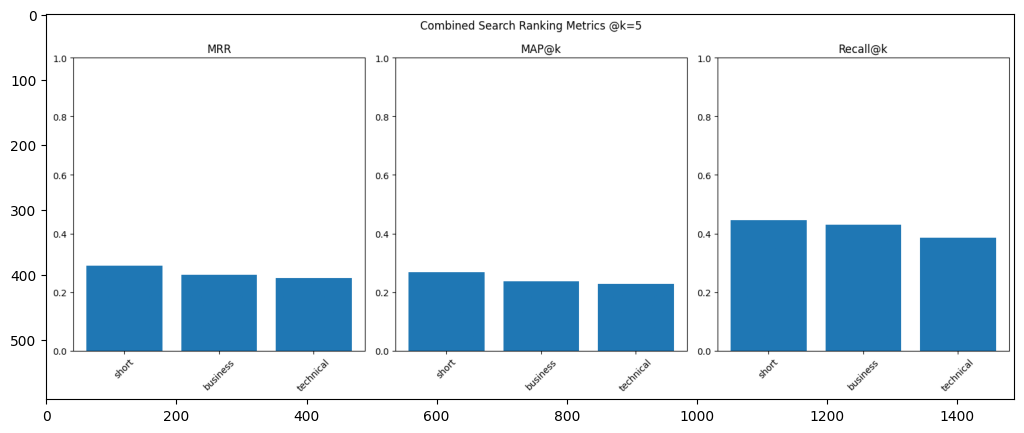

In [12]:
combined_metrics_path_5 = combine_search_ranking_metrics(
    metrics_paths=metrics_paths,
    database_name=DATABASE_NAME,
    column_mode="combined",
    k=5,
)
combined_plot_path_5 = plot_combined_search_ranking_metrics(
    combined_metrics_path_5,
    column_mode="combined",
    k=5
)
print("Combined metrics:", combined_metrics_path_5)
print("Combined plot:", combined_plot_path_5)
display(pd.read_excel(combined_metrics_path_5))
plt.figure(figsize=(15, 5))
plt.imshow(mpimg.imread(combined_plot_path_5))

Combined metrics: /home/user/cursor_projects/vanna-sql/data/processed/sakila/metrics/combined_search_top_10_combined.xlsx
Combined plot: /home/user/cursor_projects/vanna-sql/data/processed/sakila/plots/combined_search_top_10_combined.png


,description_style,mrr,map_at_k,recall_at_k
0,short,0.290402,0.290402,0.619362
1,business,0.259228,0.259228,0.590759
2,technical,0.247480,0.247480,0.535754


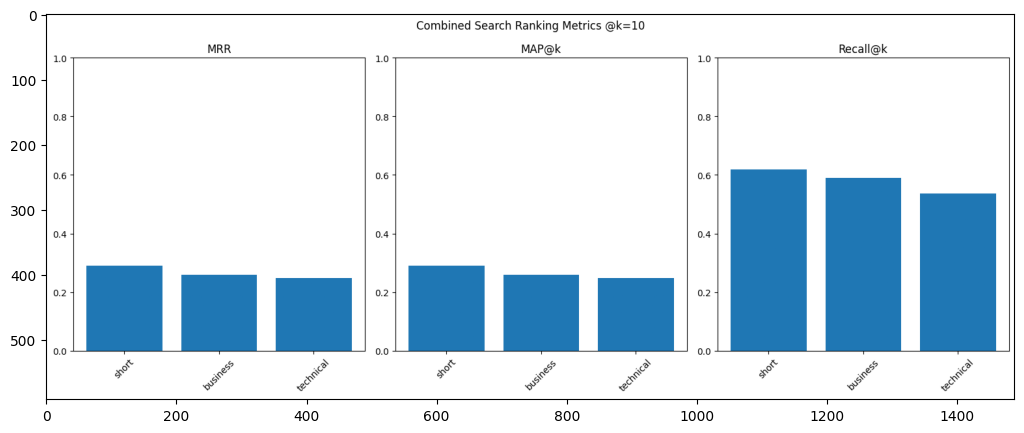

In [13]:
combined_metrics_path_10 = combine_search_ranking_metrics(
    metrics_paths=metrics_paths,
    database_name=DATABASE_NAME,
    column_mode="combined",
    k=10,
)
combined_plot_path_10 = plot_combined_search_ranking_metrics(
    combined_metrics_path_10,
    column_mode="combined",
    k=10
)
print("Combined metrics:", combined_metrics_path_10)
print("Combined plot:", combined_plot_path_10)
display(pd.read_excel(combined_metrics_path_10))
plt.figure(figsize=(15, 5))
plt.imshow(mpimg.imread(combined_plot_path_10))

## Respective metrics for top 5 and top 10

Respective metrics: /home/user/cursor_projects/vanna-sql/data/processed/sakila/metrics/combined_search_top_5_respective.xlsx
Respective plot: /home/user/cursor_projects/vanna-sql/data/processed/sakila/plots/combined_search_top_5_respective.png


,description_style,mrr,map_at_k,recall_at_k
0,short,0.462786,0.439989,0.663366
1,business,0.346828,0.326788,0.534653
2,technical,0.351359,0.331353,0.541254


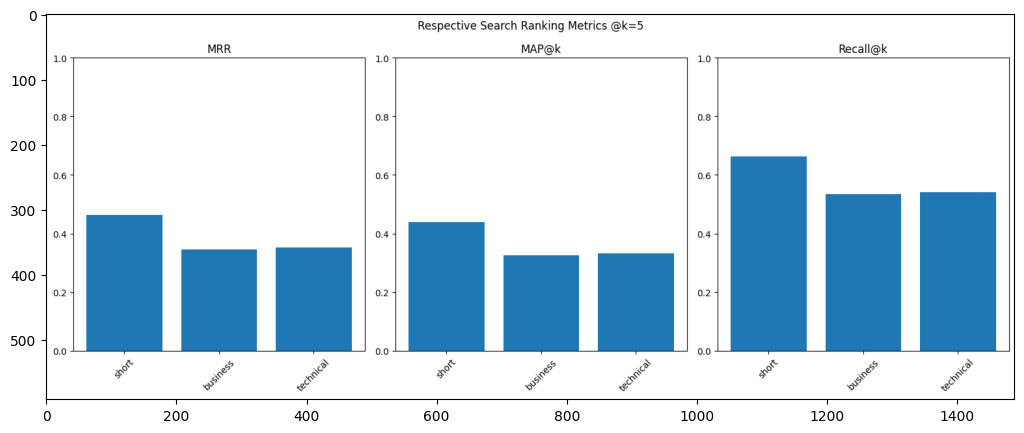

In [14]:
respective_metrics_path_5 = combine_search_ranking_metrics(
    metrics_paths=metrics_paths,
    database_name=DATABASE_NAME,
    column_mode="respective",
    k=5,
)
respective_plot_path_5 = plot_combined_search_ranking_metrics(
    respective_metrics_path_5,
    column_mode="respective",
    k=5
)
print("Respective metrics:", respective_metrics_path_5)
print("Respective plot:", respective_plot_path_5)
display(pd.read_excel(respective_metrics_path_5))
plt.figure(figsize=(15, 5))
plt.imshow(mpimg.imread(respective_plot_path_5));

Respective metrics: /home/user/cursor_projects/vanna-sql/data/processed/sakila/metrics/combined_search_top_10_respective.xlsx
Respective plot: /home/user/cursor_projects/vanna-sql/data/processed/sakila/plots/combined_search_top_10_respective.png


,description_style,mrr,map_at_k,recall_at_k
0,short,0.462786,0.462786,0.831683
1,business,0.346828,0.346828,0.679868
2,technical,0.351359,0.351359,0.696370


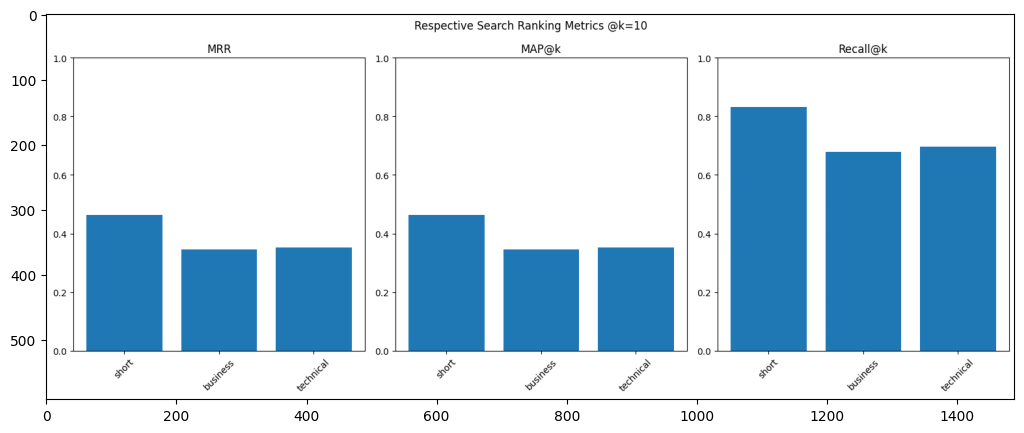

In [15]:
respective_metrics_path_10 = combine_search_ranking_metrics(
    metrics_paths=metrics_paths,
    database_name=DATABASE_NAME,
    column_mode="respective",
    k=10,
)
respective_plot_path_10 = plot_combined_search_ranking_metrics(
    respective_metrics_path_10,
    column_mode="respective",
    k=10
)
print("Respective metrics:", respective_metrics_path_10)
print("Respective plot:", respective_plot_path_10)
display(pd.read_excel(respective_metrics_path_10))
plt.figure(figsize=(15, 5))
plt.imshow(mpimg.imread(respective_plot_path_10));